Saving kaggle.json to kaggle (2).json
Dataset URL: https://www.kaggle.com/datasets/yasserh/titanic-dataset
License(s): CC0-1.0
titanic-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  titanic-dataset.zip
  inflating: Titanic-Dataset.csv     
Dataset Shape: (891, 12)


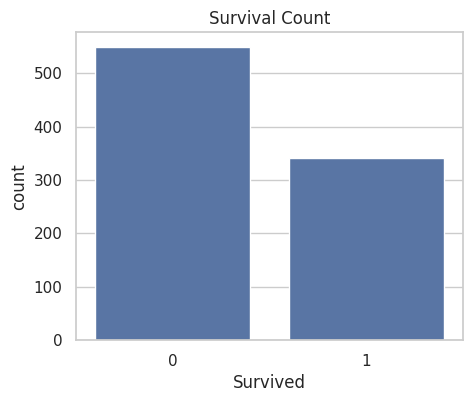

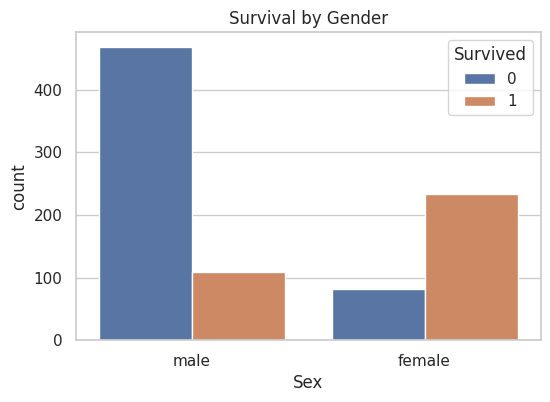

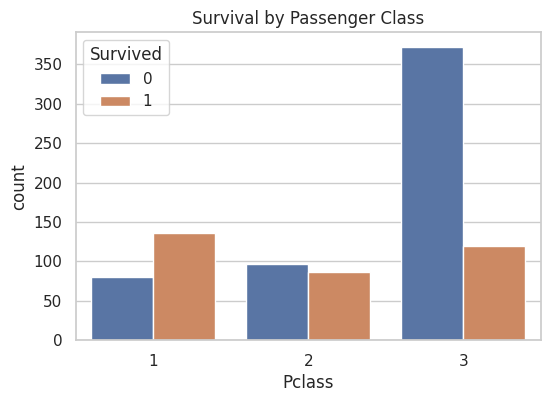

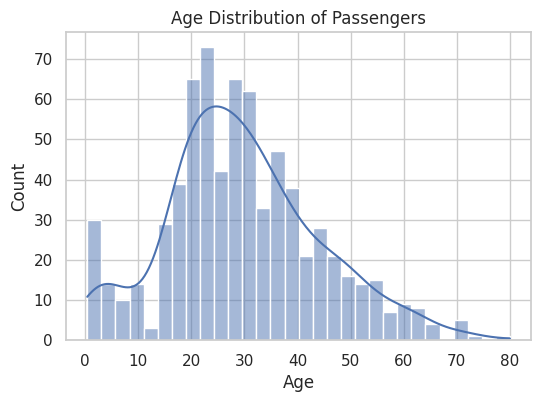

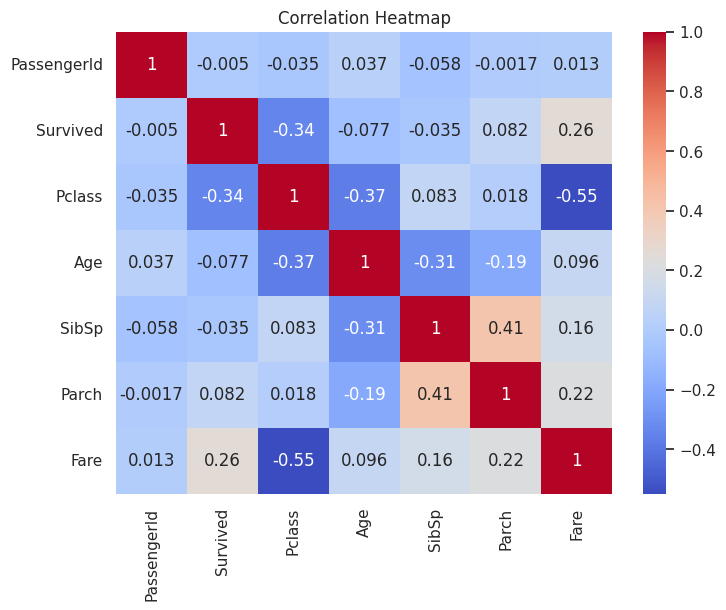


ACCURACY: 0.8156424581005587

CLASSIFICATION REPORT:

              precision    recall  f1-score   support

           0       0.81      0.90      0.85       105
           1       0.84      0.69      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.81       179


Model saved as titanic_model.joblib

Sample Prediction (0 = Died, 1 = Survived): 1


In [2]:

# ======================================================
# 1️⃣ INSTALL & SETUP KAGGLE IN COLAB
# ======================================================
!pip install kaggle

from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# ======================================================
# 2️⃣ DOWNLOAD DATASET
# ======================================================
!kaggle datasets download -d yasserh/titanic-dataset
!unzip -o titanic-dataset.zip

# ======================================================
# 3️⃣ IMPORT LIBRARIES
# ======================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

sns.set(style="whitegrid")

# ======================================================
# 4️⃣ LOAD DATA
# ======================================================
df = pd.read_csv("Titanic-Dataset.csv")
print("Dataset Shape:", df.shape)
df.head()

# ======================================================
# 5️⃣ VISUALIZATIONS
# ======================================================

# ----- Survival Count -----
plt.figure(figsize=(5,4))
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.show()

# ----- Survival by Gender -----
plt.figure(figsize=(6,4))
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.show()

# ----- Survival by Passenger Class -----
plt.figure(figsize=(6,4))
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.show()

# ----- Age Distribution -----
plt.figure(figsize=(6,4))
sns.histplot(df["Age"], kde=True, bins=30)
plt.title("Age Distribution of Passengers")
plt.show()

# ----- Correlation Heatmap -----
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# ======================================================
# 6️⃣ DATA CLEANING
# ======================================================
df2 = df.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)

df2['Age'] = df2['Age'].fillna(df2['Age'].median())
df2['Embarked'] = df2['Embarked'].fillna(df2['Embarked'].mode()[0])

# Encode categorical
le = LabelEncoder()
df2['Sex'] = le.fit_transform(df2['Sex'])
df2['Embarked'] = le.fit_transform(df2['Embarked'])

# ======================================================
# 7️⃣ TRAIN-TEST SPLIT
# ======================================================
X = df2.drop("Survived", axis=1)
y = df2["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ======================================================
# 8️⃣ MODEL TRAINING
# ======================================================
model = RandomForestClassifier(
    n_estimators=150,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

# ======================================================
# 9️⃣ EVALUATION
# ======================================================
y_pred = model.predict(X_test)

print("\nACCURACY:", accuracy_score(y_test, y_pred))
print("\nCLASSIFICATION REPORT:\n")
print(classification_report(y_test, y_pred))

# ======================================================
# 🔟 SAVE MODEL
# ======================================================
joblib.dump(model, "titanic_model.joblib")
print("\nModel saved as titanic_model.joblib")

# ======================================================
# 1️⃣1️⃣ SAMPLE PREDICTION
# ======================================================
sample = pd.DataFrame([{
    "Pclass": 3,
    "Sex": 0,
    "Age": 24,
    "SibSp": 0,
    "Parch": 0,
    "Fare": 7.25,
    "Embarked": 1
}])

prediction = model.predict(sample)[0]
print("\nSample Prediction (0 = Died, 1 = Survived):", prediction)
